# Семинар 2 — линейная модель, функция потерь и оптимизация

На лекции мы разделили четыре разные роли:

$$
\text{модель}
\quad+\quad
\text{функция потерь / целевая функция}
\quad+\quad
\text{оптимизатор}
\quad+\quad
\text{метрика}.
$$

На семинаре соберём эту схему в коде.

Сначала одну и ту же задачу линейной регрессии решим тремя способами:

1. напрямую по аналитической формуле OLS;
2. через `np.linalg.lstsq`;
3. через общий градиентный спуск.

Во второй половине занятия **оставим линейную модель и оптимизатор прежними**, но заменим MSE на функцию Хубера и посмотрим, как это изменит результат при наличии крупных выбросов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

SEED = 42

## 1. Синтетические данные для сквозного примера

Будем работать с простой контролируемой задачей:

$$
x\sim U(0,5),
\qquad
Y=10+3x+\varepsilon,
\qquad
\varepsilon\sim\mathcal N(0,1.2^2).
$$

Мы заранее знаем общую структуру зависимости, но из-за случайного шума коэффициенты, оценённые по конечной выборке, не обязаны быть ровно $10$ и $3$.

Для линейной модели со свободным членом используем матрицу

$$
X=
\begin{pmatrix}
1 & x_1\\
\vdots & \vdots\\
1 & x_n
\end{pmatrix}.
$$

Первый столбец отвечает за свободный член, второй — за коэффициент при признаке $x$.

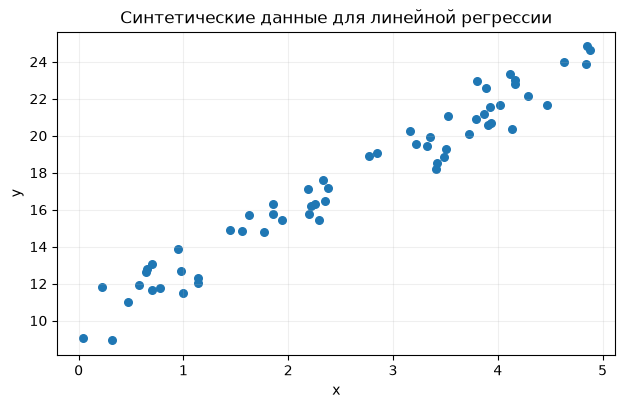

X.shape = (60, 2)
y.shape = (60,)
Первые пять строк X:
[[1.     0.0368]
 [1.     0.219 ]
 [1.     0.3191]
 [1.     0.4709]
 [1.     0.5727]]


In [2]:
rng = np.random.default_rng(SEED)

n = 60
x = np.sort(rng.uniform(0.0, 5.0, size=n))
noise = rng.normal(0.0, 1.2, size=n)
y = 10.0 + 3.0 * x + noise

# Добавляем столбец единиц, чтобы свободный член beta_0
# тоже входил в общий вектор коэффициентов beta.
X = np.column_stack([np.ones_like(x), x])

plt.figure(figsize=(7.2, 4.2))
plt.scatter(x, y, s=30)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Синтетические данные для линейной регрессии")
plt.grid(alpha=0.2)
plt.show()

print("X.shape =", X.shape)
print("y.shape =", y.shape)
print("Первые пять строк X:")
print(X[:5])

## 2. OLS по аналитической формуле

Для метода наименьших квадратов при линейно независимых столбцах $X$ мы получили

$$
\hat\beta
=
(X^\top X)^{-1}X^\top y.
$$

Сейчас буквально переведём эту запись на NumPy.

Заодно вспомним несколько базовых операций:

- `X.T` — транспонирование;
- `@` — матричное умножение;
- `np.linalg.inv(A)` — обратная матрица;
- `.shape` — размерность массива.

In [3]:
# X.T имеет форму (q, n), а X — (n, q).
# Поэтому X.T @ X имеет форму (q, q).
XtX = X.T @ X

# Правая часть нормальных уравнений имеет форму (q,).
Xty = X.T @ y

print("X.shape     =", X.shape)
print("X.T.shape   =", X.T.shape)
print("(X.T@X).shape =", XtX.shape)
print("(X.T@y).shape =", Xty.shape)

X.shape     = (60, 2)
X.T.shape   = (2, 60)
(X.T@X).shape = (2, 2)
(X.T@y).shape = (2,)


In [4]:
# Учебная реализация формулы beta_hat = (X^T X)^(-1) X^T y.
beta_formula = np.linalg.inv(XtX) @ Xty

print("\nКоэффициенты по аналитической формуле:")
print("beta_0 =", beta_formula[0])
print("beta_1 =", beta_formula[1])


Коэффициенты по аналитической формуле:
beta_0 = 9.921031740226466
beta_1 = 2.934769025586209


In [5]:
# Проверяем, что формула вернула по одному коэффициенту
# на каждый столбец матрицы X.
assert beta_formula.shape == (X.shape[1],)

# В нашем примере X имеет полный столбцовый ранг,
# поэтому X.T @ X должна быть обратимой.
assert np.linalg.matrix_rank(X) == X.shape[1]

print("Базовые проверки аналитического решения пройдены.")

Базовые проверки аналитического решения пройдены.


## 3. Та же задача через `np.linalg.lstsq`

Аналитическая формула полезна для понимания, но на практике обычно не вычисляют $(X^\top X)^{-1}$ явно.

`np.linalg.lstsq` решает исходную задачу наименьших квадратов:

$$
\hat\beta
\in
\arg\min_\beta
\|y-X\beta\|_2^2.
$$

Функция возвращает не только коэффициенты, но и дополнительную информацию о решении

Сейчас нас интересует главный вопрос: **получим ли мы те же прогнозы и коэффициенты, что и по аналитической формуле?**

In [7]:
beta_lstsq, residuals_lstsq, rank_lstsq, singular_values = np.linalg.lstsq(
    X,
    y
)

print("Коэффициенты lstsq:", beta_lstsq)
print("Ранг X:", rank_lstsq)

Коэффициенты lstsq: [9.921  2.9348]
Ранг X: 2


In [8]:
# Строим прогнозы двумя способами.
pred_formula = X @ beta_formula
pred_lstsq = X @ beta_lstsq

comparison_ols = pd.DataFrame(
    {
        "аналитическая формула": beta_formula,
        "lstsq": beta_lstsq,
        "разность": beta_formula - beta_lstsq,
    },
    index=["свободный член", "коэффициент при x"],
)

display(comparison_ols)

,аналитическая формула,lstsq,разность
свободный член,9.921032,9.921032,7.105427e-15
коэффициент при x,2.934769,2.934769,-3.108624e-15


In [9]:
# Проверяем, что два способа дали практически одинаковые коэффициенты.
assert np.allclose(beta_formula, beta_lstsq)

# Отдельно проверяем прогнозы: именно они являются результатом работы модели.
assert np.allclose(pred_formula, pred_lstsq)

print("Аналитическая формула и lstsq дают одно и то же OLS-решение с машинной точностью.")

Аналитическая формула и lstsq дают одно и то же OLS-решение с машинной точностью.


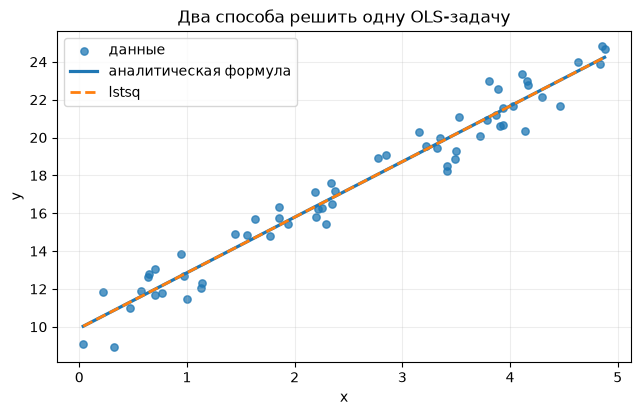

In [10]:
xx = np.linspace(x.min(), x.max(), 200)
XX = np.column_stack([np.ones_like(xx), xx])

plt.figure(figsize=(7.4, 4.3))
plt.scatter(x, y, s=28, alpha=0.75, label="данные")
plt.plot(
    xx,
    XX @ beta_formula,
    linewidth=2.3,
    label="аналитическая формула",
)
plt.plot(
    xx,
    XX @ beta_lstsq,
    linewidth=2.0,
    linestyle="--",
    label="lstsq",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Два способа решить одну OLS-задачу")
plt.legend()
plt.grid(alpha=0.22)
plt.show()

## 4. Один шаг градиентного спуска

Перед линейной регрессией разберём механику на функции одной переменной:

$$
f(w)=(w-3)^2,
\qquad
f'(w)=2(w-3).
$$

Минимум находится в $w=3$, но алгоритму эту точку заранее не сообщаем.

Правило шага:

$$
w_{t+1}=w_t-\eta f'(w_t).
$$

Пусть $w_0=0$ и $\eta=0.1$. Пока $w<3$, производная отрицательна, поэтому вычитание отрицательного числа двигает параметр вправо — к минимуму.

шаг 0: w= 0.0000, f(w)=  9.0000, f'(w)= -6.0000
шаг 1: w= 0.6000, f(w)=  5.7600, f'(w)= -4.8000
шаг 2: w= 1.0800, f(w)=  3.6864, f'(w)= -3.8400
шаг 3: w= 1.4640, f(w)=  2.3593, f'(w)= -3.0720
шаг 4: w= 1.7712, f(w)=  1.5099, f'(w)= -2.4576


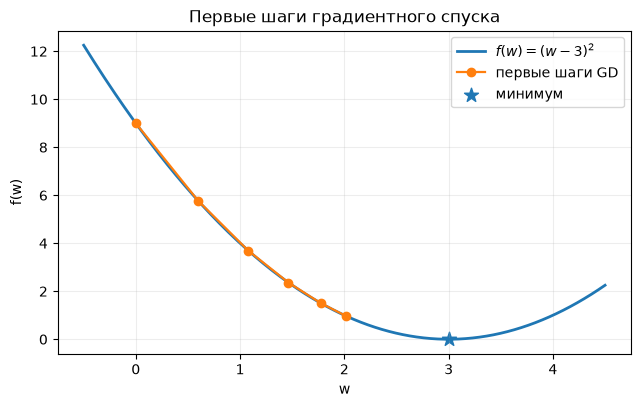

In [11]:
w = 0.0
learning_rate = 0.1
w_manual = [w]

for step in range(5):
    value = (w - 3.0) ** 2
    grad = 2.0 * (w - 3.0)

    print(
        f"шаг {step}: "
        f"w={w:7.4f}, "
        f"f(w)={value:8.4f}, "
        f"f'(w)={grad:8.4f}"
    )

    # Главная операция градиентного спуска:
    # новое значение = старое значение - шаг * производная.
    w = w - learning_rate * grad
    w_manual.append(w)

w_grid = np.linspace(-0.5, 4.5, 300)
f_grid = (w_grid - 3.0) ** 2
f_manual = (np.asarray(w_manual) - 3.0) ** 2

plt.figure(figsize=(7.4, 4.2))
plt.plot(w_grid, f_grid, linewidth=2, label=r"$f(w)=(w-3)^2$")
plt.plot(
    w_manual,
    f_manual,
    marker="o",
    linewidth=1.6,
    label="первые шаги GD",
)
plt.scatter([3.0], [0.0], marker="*", s=110, label="минимум")
plt.xlabel("w")
plt.ylabel("f(w)")
plt.title("Первые шаги градиентного спуска")
plt.legend()
plt.grid(alpha=0.22)
plt.show()

## 5. Один общий `gradient_descent`

Теперь запишем оптимизатор один раз так, чтобы он не знал ничего о конкретной модели.

Ему нужны:

- начальные параметры `theta0`;
- функция, значение которой минимизируем;
- функция её градиента;
- темп обучения;
- число шагов;
- при необходимости — фиксированные данные через `fixed_args`.

Например,

```python
fixed_args=(X, y)
```

превращает

```python
grad_fn(theta, *fixed_args)
```

в

```python
grad_fn(theta, X, y)
```

Оптимизатор изменяет только `theta`. Данные `X` и `y` на протяжении запуска остаются фиксированными.

### Что важно в реализации

Строка

```python
theta = np.array(theta0, dtype=float, copy=True)
```

сразу делает три вещи:

1. приводит начальные параметры к NumPy-массиву;
2. переводит их в `float`, потому что шаги обычно дробные;
3. создаёт независимую копию, чтобы функция не меняла объект `theta0` снаружи.

Внутри цикла особенно важны три строки. Они снабжены подробными комментариями прямо в коде.

In [12]:
def gradient_descent(
    theta0,
    objective_fn,
    grad_fn,
    learning_rate,
    n_steps,
    fixed_args=(),
):
    """
    Минимизирует целевую функцию градиентным спуском с постоянным шагом.

    Parameters
    ----------
    theta0 : array-like, shape (d,)
        Начальное значение вектора из d параметров.
    objective_fn : callable
        Целевая функция. Первый аргумент — theta; после него
        при необходимости передаются элементы fixed_args.
    grad_fn : callable
        Функция градиента. Возвращает одномерный массив длины d.
    learning_rate : float
        Положительный темп обучения.
    n_steps : int
        Число обновлений параметров.
    fixed_args : tuple, default=()
        Неизменяемые дополнительные аргументы.
        Для линейной регрессии это, например, (X, y).

    Returns
    -------
    theta : np.ndarray, shape (d,)
        Параметры после последнего шага.
    history : dict[str, np.ndarray]
        История параметров и значений целевой функции.
    """
    theta = np.array(theta0, dtype=float, copy=True)

    history = {
        "theta": [theta.copy()],
        "objective": [float(objective_fn(theta, *fixed_args))],
    }

    for _ in range(n_steps):
        # 1. Считаем локальную информацию в текущей точке.
        # fixed_args распаковываются после theta:
        # grad_fn(theta, X, y), grad_fn(theta) и т. д.
        grad = np.array(
            grad_fn(theta, *fixed_args),
            dtype=float,
        )

        # 2. Делаем шаг в направлении антиградиента.
        # Именно эта строка реализует правило
        # theta_(t+1) = theta_t - eta * grad.
        theta = theta - learning_rate * grad

        # 3. Сохраняем отдельный снимок текущего состояния.
        # copy() важен: без него история могла бы хранить ссылки
        # на один и тот же изменяемый массив.
        history["theta"].append(theta.copy())

        # Значение objective сохраняем уже в новой точке,
        # чтобы история параметров и история функции были синхронны.
        history["objective"].append(
            float(objective_fn(theta, *fixed_args))
        )

    # Массивы удобнее списков для последующего анализа и графиков.
    history["theta"] = np.asarray(history["theta"])
    history["objective"] = np.asarray(history["objective"])

    return theta, history

### Проверяем контракт функции

`assert` — маленький автоматический тест. Если условие истинно, код продолжает работу; если нет, Python останавливается с `AssertionError`.

Ниже каждый тест проверяет отдельное обещание нашей функции. Писать систему тестирования с нуля здесь не нужно — важно понимать, что именно мы проверяем.

In [13]:
def parabola_func(theta):
    """f(w) = (w - 3)^2 для theta = [w]."""
    w = theta[0]
    return (w - 3.0) ** 2


def parabola_grad(theta):
    """Градиент параболы: массив из одной производной df/dw."""
    w = theta[0]
    return np.array([2.0 * (w - 3.0)])


theta0_test = np.array([0.0])
theta0_before = theta0_test.copy()

theta_final, parabola_history = gradient_descent(
    theta0=theta0_test,
    objective_fn=parabola_func,
    grad_fn=parabola_grad,
    learning_rate=0.1,
    n_steps=40,
)

# Проверяем, что функция не изменила переданный снаружи theta0.
assert np.array_equal(theta0_test, theta0_before)

# Проверяем размер итогового вектора параметров.
assert theta_final.shape == (1,)

# После 40 обновлений должно быть 41 состояние:
# стартовая точка + состояние после каждого шага.
assert parabola_history["theta"].shape == (41, 1)
assert parabola_history["objective"].shape == (41,)

# Проверяем отсутствие NaN и бесконечностей.
assert np.isfinite(theta_final).all()

# Для этой простой функции известен точный минимум w = 3.
assert abs(theta_final[0] - 3.0) < 1e-3

# Финальное значение функции должно быть меньше стартового.
assert (
    parabola_history["objective"][-1]
    < parabola_history["objective"][0]
)

print("Все проверки gradient_descent пройдены.")
print("Финальное w:", theta_final[0])
print("Финальное f(w):", parabola_history["objective"][-1])

Все проверки gradient_descent пройдены.
Финальное w: 2.9996012316012646
Финальное f(w): 1.5901623583001677e-07


### Как влияет темп обучения

На той же параболе сравним три значения:

$$
\eta=0.05,\qquad
\eta=0.8,\qquad
\eta=1.1.
$$

До запуска попробуйте распределить их по трём режимам:

- медленная сходимость;
- затухающие перепрыгивания через минимум;
- расходимость.

Числа относятся именно к этой параболе. В другой задаче безопасный масштаб $\eta$ будет другим.

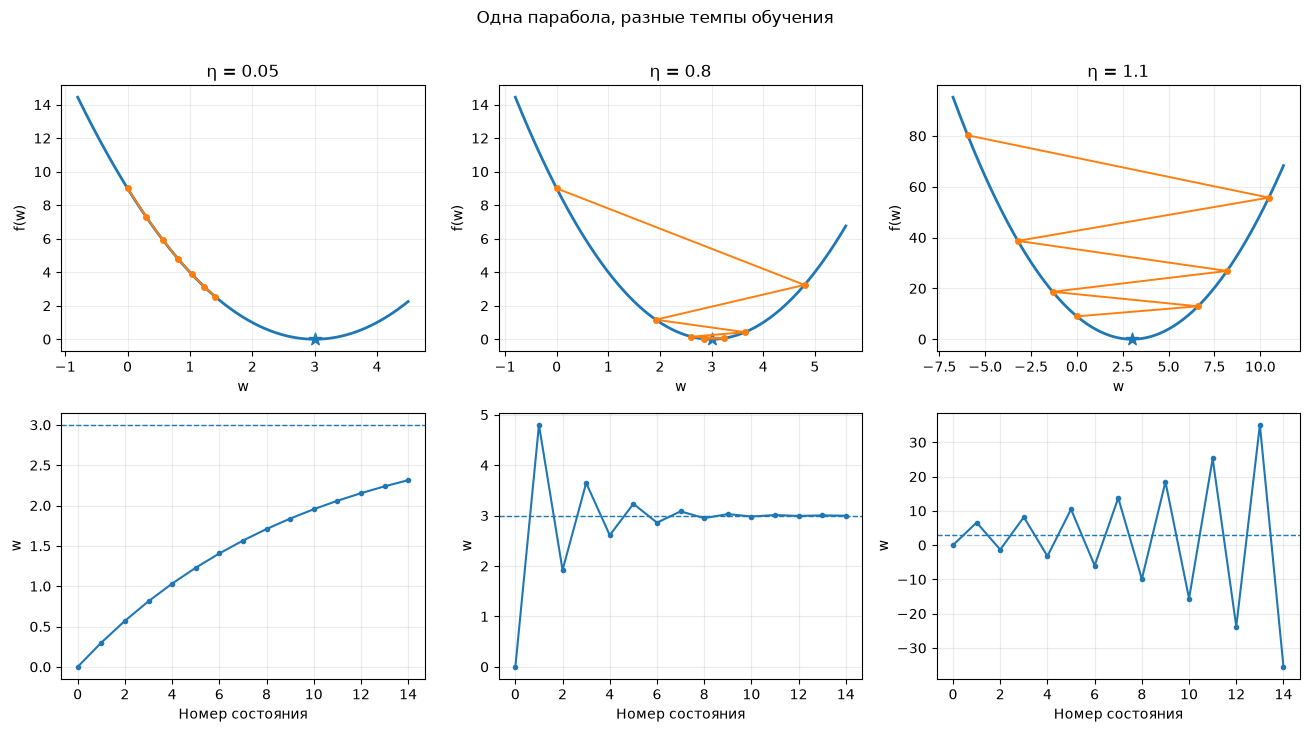

In [14]:
learning_rates = [0.05, 0.8, 1.1]

fig, axes = plt.subplots(2, 3, figsize=(13.2, 7.2))

for col, eta in enumerate(learning_rates):
    theta_eta, history_eta = gradient_descent(
        theta0=np.array([0.0]),
        objective_fn=parabola_func,
        grad_fn=parabola_grad,
        learning_rate=eta,
        n_steps=14,
    )

    w_path = history_eta["theta"][:, 0]

    # Верхний ряд: первые шаги непосредственно на параболе.
    n_show = min(7, len(w_path))
    w_visible = w_path[:n_show]
    w_min = min(-0.5, w_visible.min() - 0.8)
    w_max = max(4.5, w_visible.max() + 0.8)
    grid = np.linspace(w_min, w_max, 350)

    ax_top = axes[0, col]
    ax_top.plot(grid, (grid - 3.0) ** 2, linewidth=2)
    ax_top.plot(
        w_visible,
        (w_visible - 3.0) ** 2,
        marker="o",
        linewidth=1.4,
        markersize=4,
    )
    ax_top.scatter([3.0], [0.0], marker="*", s=85)
    ax_top.set_title(f"η = {eta}")
    ax_top.set_xlabel("w")
    ax_top.set_ylabel("f(w)")
    ax_top.grid(alpha=0.22)

    # Нижний ряд: как меняется параметр w по итерациям.
    ax_bottom = axes[1, col]
    ax_bottom.plot(
        np.arange(len(w_path)),
        w_path,
        marker="o",
        markersize=3,
    )
    ax_bottom.axhline(3.0, linestyle="--", linewidth=1)
    ax_bottom.set_xlabel("Номер состояния")
    ax_bottom.set_ylabel("w")
    ax_bottom.grid(alpha=0.25)

fig.suptitle("Одна парабола, разные темпы обучения", y=1.01)
plt.tight_layout()
plt.show()

## 6. Двумерный случай

Теперь параметр состоит из двух координат:

$$
\theta=
\begin{pmatrix}
w_1\\
w_2
\end{pmatrix},
$$

а функция равна

$$
f(w_1,w_2)
=
(w_1-0.6)^2
+
3(w_2+0.4)^2.
$$

Её градиент:

$$
\nabla f(w_1,w_2)
=
\begin{pmatrix}
2(w_1-0.6)\\
6(w_2+0.4)
\end{pmatrix}.
$$

Здесь ничего не пишем с нуля: и функция, и градиент готовы. Задача блока — увидеть, что **сам `gradient_descent` менять не пришлось**. Параметр просто стал вектором.

In [15]:
def quadratic_func(theta):
    """Квадратичная функция двух переменных."""
    w1, w2 = theta
    return (w1 - 0.6) ** 2 + 3.0 * (w2 + 0.4) ** 2


def quadratic_gradient(theta):
    """Две частные производные: по w1 и по w2."""
    w1, w2 = theta
    return np.array([
        2.0 * (w1 - 0.6),
        6.0 * (w2 + 0.4),
    ])


# В известной точке минимума градиент должен быть нулевым.
assert np.allclose(
    quadratic_gradient(np.array([0.6, -0.4])),
    [0.0, 0.0],
)

# В другой точке вручную ожидаем [2, 6].
# Этот тест проверяет порядок координат и коэффициенты в формуле.
assert np.allclose(
    quadratic_gradient(np.array([1.6, 0.6])),
    [2.0, 6.0],
)

theta_2d, history_2d = gradient_descent(
    theta0=np.array([-2.0, 2.0]),
    objective_fn=quadratic_func,
    grad_fn=quadratic_gradient,
    learning_rate=0.12,
    n_steps=30,
)

print("Финальные параметры:", theta_2d)
print("Финальное значение функции:", history_2d["objective"][-1])

Финальные параметры: [ 0.5993 -0.4   ]
Финальное значение функции: 4.772679078488248e-07


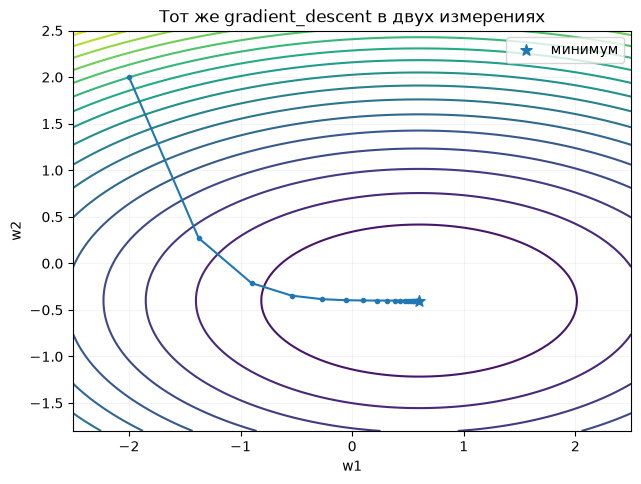

In [16]:
w1_grid = np.linspace(-2.5, 2.5, 220)
w2_grid = np.linspace(-1.8, 2.5, 220)
W1, W2 = np.meshgrid(w1_grid, w2_grid)
Z = (W1 - 0.6) ** 2 + 3.0 * (W2 + 0.4) ** 2

path = history_2d["theta"]

plt.figure(figsize=(7.2, 5.2))
plt.contour(W1, W2, Z, levels=18)
plt.plot(
    path[:, 0],
    path[:, 1],
    marker="o",
    markersize=3,
    linewidth=1.5,
)
plt.scatter([0.6], [-0.4], s=70, marker="*", label="минимум")
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Тот же gradient_descent в двух измерениях")
plt.legend()
plt.grid(alpha=0.15)
plt.show()

## 7. Линейная регрессия через тот же градиентный спуск

Возвращаемся к нашей матрице $X$ и вектору $y$.

Модель:

$$
\hat y=X\beta.
$$

Целевая функция:

$$
R(\beta)
=
\frac1n
\|y-X\beta\|_2^2.
$$

Важно: это **та же OLS-задача**, которую мы уже решили аналитической формулой и через `lstsq`. Теперь меняется только способ поиска коэффициентов.

In [17]:
def linear_predict(beta, X):
    """Строит прогнозы линейной модели X @ beta."""
    return X @ beta


def mse_loss(beta, X, y):
    """Возвращает средний квадрат остатка для линейной модели."""
    residuals = y - linear_predict(beta, X)
    return float(np.mean(residuals ** 2))


beta_demo = np.array([10.0, 3.0])

# Проверяем, что прогноз получается по одному числу на объект.
assert linear_predict(beta_demo, X).shape == y.shape

# Целевая функция должна возвращать одно число.
assert np.isscalar(mse_loss(beta_demo, X, y))

print("linear_predict и mse_loss работают.")

linear_predict и mse_loss работают.


### Градиент MSE

Из лекции:

$$
\boxed{
\nabla_\beta R(\beta)
=
-\frac{2}{n}
X^\top(y-X\beta)
}.
$$

Проследим размеры:

- `y - X @ beta` — $n$ остатков, форма `(n,)`;
- `X.T @ residuals` — по одной компоненте на коэффициент, форма `(q,)`;
- итоговый градиент имеет ту же форму, что и `beta`.

Здесь функция уже готова: на семинаре важнее подробно прочитать её, чем снова переписывать формулу с доски.

In [18]:
def mse_gradient(beta, X, y):
    """Градиент среднего квадрата ошибки по коэффициентам beta."""
    beta = np.asarray(beta, dtype=float)

    # 1. Ошибка текущей модели на каждом объекте.
    residuals = y - X @ beta

    # 2. X.T собирает вклад всех остатков
    #    в каждую координату вектора beta.
    gradient = -(2.0 / len(y)) * X.T @ residuals

    return gradient


# Маленький пример, в котором ответ легко проверить вручную.
X_check = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
])
y_check = np.array([1.0, 3.0])
beta_check = np.array([0.0, 0.0])

# residuals = [1, 3]
# X.T @ residuals = [4, 3]
# -(2 / 2) * [4, 3] = [-4, -3]
assert np.allclose(
    mse_gradient(beta_check, X_check, y_check),
    [-4.0, -3.0],
)

print("Проверка mse_gradient пройдена.")

Проверка mse_gradient пройдена.


In [21]:
beta_gd, linear_history = gradient_descent(
    theta0=np.zeros(X.shape[1]),
    objective_fn=mse_loss,
    grad_fn=mse_gradient,
    learning_rate=0.05,
    n_steps=800,
    fixed_args=(X, y),
)

print("Коэффициенты GD:", beta_gd)

Коэффициенты GD: [9.921  2.9348]


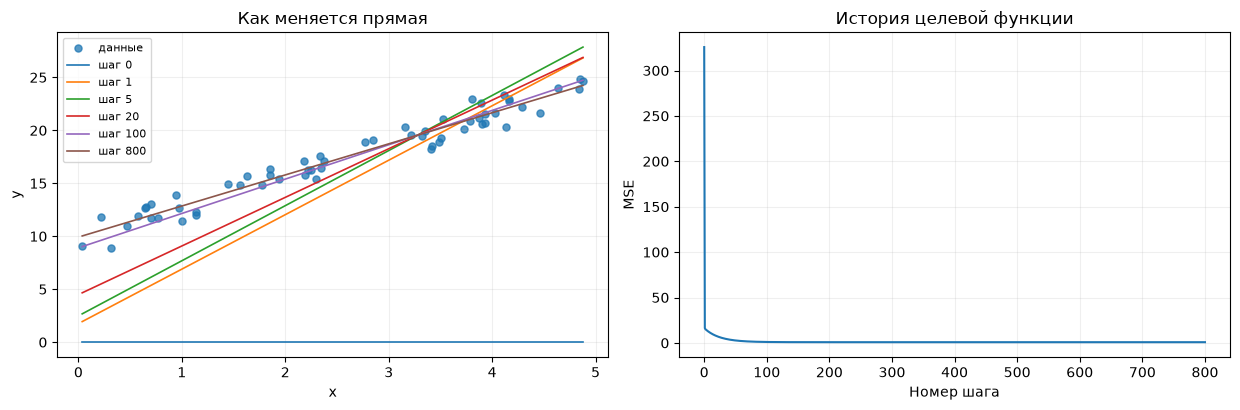

In [22]:
selected_steps = [0, 1, 5, 20, 100, 800]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

# Левая панель: как меняется сама прямая.
axes[0].scatter(x, y, s=26, alpha=0.75, label="данные")

for step in selected_steps:
    beta_step = linear_history["theta"][step]
    axes[0].plot(
        xx,
        XX @ beta_step,
        linewidth=1.2,
        label=f"шаг {step}",
    )

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Как меняется прямая")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# Правая панель: как уменьшается целевая функция.
axes[1].plot(linear_history["objective"])
axes[1].set_xlabel("Номер шага")
axes[1].set_ylabel("MSE")
axes[1].set_title("История целевой функции")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Три способа решить одну OLS-задачу

Теперь у нас есть три набора коэффициентов:

1. `beta_formula` — аналитическая формула;
2. `beta_lstsq` — специализированный численный решатель;
3. `beta_gd` — итеративный градиентный спуск.

Во всех трёх случаях:

- семейство моделей одно;
- целевая функция одна — MSE / RSS;
- меняется только способ поиска параметров.

,аналитическая формула,lstsq,GD
свободный член,9.921032,9.921032,9.921031
коэффициент при x,2.934769,2.934769,2.934769


Расстояние formula ↔ lstsq: 7.755684626330685e-15
Расстояние GD ↔ lstsq: 4.435129633645058e-07


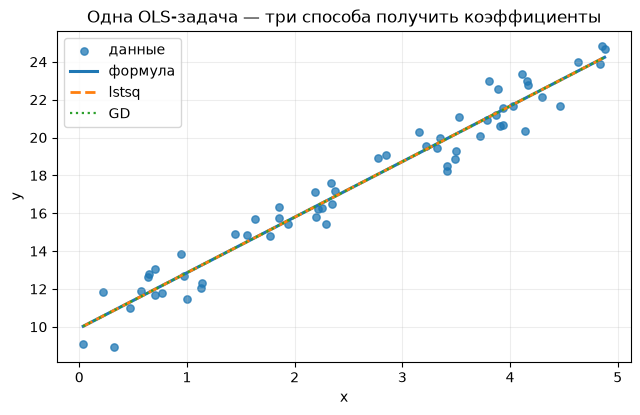

In [23]:
comparison_three = pd.DataFrame(
    {
        "аналитическая формула": beta_formula,
        "lstsq": beta_lstsq,
        "GD": beta_gd,
    },
    index=["свободный член", "коэффициент при x"],
)

display(comparison_three)

print(
    "Расстояние formula ↔ lstsq:",
    np.linalg.norm(beta_formula - beta_lstsq),
)
print(
    "Расстояние GD ↔ lstsq:",
    np.linalg.norm(beta_gd - beta_lstsq),
)

# Формула и lstsq должны совпасть практически до машинной точности.
assert np.allclose(beta_formula, beta_lstsq)

# GD — итеративный метод, поэтому допускаем маленькую численную погрешность.
assert np.linalg.norm(beta_gd - beta_lstsq) < 1e-4

plt.figure(figsize=(7.4, 4.3))
plt.scatter(x, y, s=28, alpha=0.75, label="данные")
plt.plot(xx, XX @ beta_formula, linewidth=2.2, label="формула")
plt.plot(
    xx,
    XX @ beta_lstsq,
    linewidth=2.0,
    linestyle="--",
    label="lstsq",
)
plt.plot(
    xx,
    XX @ beta_gd,
    linewidth=1.6,
    linestyle=":",
    label="GD",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Одна OLS-задача — три способа получить коэффициенты")
plt.legend()
plt.grid(alpha=0.22)
plt.show()

# Самостоятельная работа

До конца занятия работаем с тем же линейным семейством

$$
\hat y=X\beta,
$$

и тем же общим `gradient_descent`.

Теперь изменим **функцию потерь**.

Когда решение готово, можно показать экран и за 2–3 минуты объяснить:

- что вы реализовали;
- как изменились коэффициенты и прямая;
- почему MSE и Huber ведут себя по-разному.

Остальные в это время продолжают работу.

Если не успели закончить на занятии, сохраните notebook и отправьте его преподавателю на проверку.

## 9. Добавляем несколько крупных выбросов

Сделаем копию целевой переменной и **искусственно увеличим три значения $y$ у объектов с большими $x$**.

Такой приём иногда называют загрязнением (*contamination*) данных. Здесь всё полностью контролируемо: мы сами знаем, какие точки изменили и зачем.

Переменную назовём просто `y_with_outliers`.

До запуска сформулируйте прогноз:

> Какая прямая сильнее повернётся к трём крупным выбросам — обученная по MSE или по функции Хубера?

In [ ]:
y_with_outliers = y.copy()

# Выбираем три объекта в правой части диапазона x.
# Большие отклонения именно здесь заметно влияют и на наклон прямой.
outlier_idx = np.array([48, 54, 59])

# Искусственно увеличиваем только их целевые значения.
y_with_outliers[outlier_idx] += np.array([25.0, 32.0, 38.0])

plt.figure(figsize=(7.2, 4.2))
plt.scatter(x, y_with_outliers, s=30, label="данные с выбросами")
plt.scatter(
    x[outlier_idx],
    y_with_outliers[outlier_idx],
    s=85,
    marker="x",
    linewidths=2.0,
    label="искусственно изменённые точки",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Три крупных выброса при больших x")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Задание A. Обучите MSE-модель на данных с выбросами

Все функции уже готовы.

Нужно повторно запустить **тот же** `gradient_descent`, но теперь передать `y_with_outliers`.

Параметры оптимизатора уже подобраны. Вам остаётся указать фиксированные данные в `fixed_args`.

После запуска сравните новые коэффициенты с `beta_lstsq`, полученным на исходных данных.

In [ ]:
beta_mse_outliers, mse_outliers_history = gradient_descent(
    theta0=np.zeros(X.shape[1]),
    objective_fn=...,
    grad_fn=...,
    learning_rate=0.05,
    n_steps=800,

    # TODO: передайте сюда матрицу X и новую целевую переменную.
    fixed_args=(..., ...),
)

print("Коэффициенты MSE на данных с выбросами:", beta_mse_outliers)
print(
    "Расстояние до lstsq на исходных данных:",
    np.linalg.norm(beta_mse_outliers - beta_lstsq),
)

## 10. Функция Хубера и `np.clip`

Для остатка $r=y-\hat y$ функция Хубера равна

$$
L_\delta(r)
=
\begin{cases}
\frac12r^2, & |r|\le\delta,\\[3pt]
\delta\left(|r|-\frac12\delta\right), & |r|>\delta.
\end{cases}
$$

Её производная по остатку:

$$
L_\delta'(r)
=
\begin{cases}
-\delta, & r<-\delta,\\
r, & |r|\le\delta,\\
\delta, & r>\delta.
\end{cases}
$$

То есть внутри $[-\delta,\delta]$ производная равна самому остатку, а в хвостах её модуль перестаёт расти.

Именно это поэлементно делает

```python
np.clip(values, lower, upper)
```

Для массива остатков выражение

```python
np.clip(residuals, -delta, delta)
```

сразу даёт значения $L_\delta'(r_i)$ для всех объектов.

In [ ]:
clip_demo = np.array([-5.0, -1.0, 0.0, 1.5, 7.0])

# Значения меньше -2 заменяются на -2,
# значения больше 2 — на 2,
# остальные остаются без изменений.
clipped_demo = np.clip(clip_demo, -2.0, 2.0)

print("Исходный массив:", clip_demo)
print("После np.clip:", clipped_demo)

# Проверяем, что np.clip сделал именно то, что ожидаем.
assert np.allclose(
    clipped_demo,
    [-2.0, -1.0, 0.0, 1.5, 2.0],
)

Для линейной модели по правилу цепочки:

$$
\boxed{
\nabla_\beta R_{\mathrm{Huber}}(\beta)
=
-\frac1n
X^\top
\operatorname{clip}(y-X\beta,-\delta,\delta)
}.
$$

Схема вычисления остаётся той же:

1. прогнозы;
2. остатки;
3. преобразование остатков;
4. умножение на $X^\top$.

Меняется то, **как функция потерь преобразует крупные остатки**.

In [ ]:
def huber_loss(beta, X, y, delta=2.0):
    """Среднее значение функции Хубера для линейной модели."""
    beta = np.asarray(beta, dtype=float)

    residuals = y - X @ beta
    abs_residuals = np.abs(residuals)

    # np.where применяет кусочную формулу сразу ко всему массиву.
    per_object = np.where(
        abs_residuals <= delta,
        0.5 * residuals ** 2,
        delta * (abs_residuals - 0.5 * delta),
    )

    return float(np.mean(per_object))

## Задание B. Реализуйте `huber_gradient`

Нужно дописать только три логических шага:

1. получить остатки;
2. ограничить их через `np.clip`;
3. применить матричную формулу выше.

Сам `gradient_descent` менять нельзя и не нужно.

In [ ]:
def huber_gradient(beta, X, y, delta=2.0):
    """
    Градиент среднего критерия Хубера по коэффициентам beta.

    Returns
    -------
    np.ndarray, shape (q,)
        По одной компоненте градиента на каждый коэффициент.
    """
    beta = np.asarray(beta, dtype=float)

    # TODO 1: вычислите текущие остатки.
    residuals = ...

    # TODO 2: ограничьте их диапазоном [-delta, delta].
    clipped_residuals = ...

    # TODO 3: соберите градиент по всем объектам.
    gradient = ...

    return gradient

In [ ]:
# Проверяем huber_gradient на двух объектах,
# где ожидаемый ответ легко получить вручную.
X_huber_check = np.array([
    [1.0, 0.0],
    [1.0, 1.0],
])
y_huber_check = np.array([0.0, 3.0])
beta_huber_check = np.array([0.0, 0.0])

# При delta=1:
# residuals = [0, 3]
# clip(residuals, -1, 1) = [0, 1]
# -(1 / 2) * X.T @ [0, 1] = [-0.5, -0.5]
assert np.allclose(
    huber_gradient(
        beta_huber_check,
        X_huber_check,
        y_huber_check,
        delta=1.0,
    ),
    [-0.5, -0.5],
)

print("Проверка huber_gradient пройдена.")

## Задание C. Обучите Huber-модель

Используем **тот же `gradient_descent`**, что и раньше.

Теперь нужно правильно передать:

- `huber_loss`;
- `huber_gradient`;
- данные с выбросами;
- $\delta=2$.

Темп обучения и число шагов уже подобраны, чтобы задача не превращалась в подбор гиперпараметров.

In [ ]:
delta = 2.0

beta_huber, huber_history = gradient_descent(
    theta0=np.zeros(X.shape[1]),

    # TODO: укажите соответствующие objective и gradient.
    objective_fn=...,
    grad_fn=...,

    learning_rate=0.08,
    n_steps=1200,

    # TODO: передайте X, y_with_outliers и delta.
    fixed_args=(..., ..., ...),
)

print("Коэффициенты Huber:", beta_huber)

## Задание D. Сравните MSE и Huber

После выполнения предыдущих заданий код ниже строит три линии:

- OLS на исходных данных без искусственных выбросов;
- MSE на данных с выбросами;
- Huber на тех же данных с выбросами.

Обратите внимание: **семейство моделей остаётся линейным**, а для MSE и Huber мы использовали один и тот же общий optimizer.

In [ ]:
beta_clean_reference = beta_lstsq

plt.figure(figsize=(8.2, 4.8))
plt.scatter(
    x,
    y_with_outliers,
    s=27,
    alpha=0.75,
    label="данные с выбросами",
)
plt.scatter(
    x[outlier_idx],
    y_with_outliers[outlier_idx],
    s=85,
    marker="x",
    linewidths=2.0,
    label="искусственные выбросы",
)

plt.plot(
    xx,
    XX @ beta_clean_reference,
    linewidth=2.0,
    linestyle="--",
    label="lstsq на исходных данных",
)
plt.plot(
    xx,
    XX @ beta_mse_outliers,
    linewidth=2.0,
    label="MSE на данных с выбросами",
)
plt.plot(
    xx,
    XX @ beta_huber,
    linewidth=2.0,
    label="Huber на данных с выбросами",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Одна модель и один optimizer — разные функции потерь")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Сравнение по метрикам

Все метрики ниже считаются **на тех же данных с выбросами**, на которых подбирались параметры.

Это важно: сейчас мы не исследуем обобщающую способность и не делаем train/test split. Цель эксперимента — увидеть, как две функции потерь по-разному выбирают параметры на одном контролируемом наборе.

Посчитаем:

$$
\mathrm{MSE},
\qquad
\mathrm{RMSE},
\qquad
\mathrm{MAE},
\qquad
\mathrm{MAPE}.
$$

В нашем синтетическом наборе $y$ положительны и достаточно далеки от нуля, поэтому MAPE здесь можно использовать без отдельной обработки нулей.

In [ ]:
def regression_metrics(beta, X, y):
    """MSE, RMSE, MAE и MAPE (%) для фиксированных коэффициентов."""
    predictions = X @ beta
    residuals = y - predictions

    mse = np.mean(residuals ** 2)

    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": np.mean(np.abs(residuals)),
        "MAPE, %": 100.0 * np.mean(np.abs(residuals / y)),
    }


rows = []

for name, beta in [
    ("MSE", beta_mse_outliers),
    ("Huber", beta_huber),
]:
    metrics = regression_metrics(beta, X, y_with_outliers)

    rows.append(
        {
            "вариант": name,
            **metrics,
            "beta_0": beta[0],
            "beta_1": beta[1],
            "расстояние до исходного lstsq": np.linalg.norm(
                beta - beta_clean_reference
            ),
        }
    )

metrics_table = pd.DataFrame(rows).set_index("вариант")
display(metrics_table.round(4))

### Вопросы

1. Какая прямая сильнее изменила наклон из-за трёх крупных выбросов?
2. Почему вариант, обученный по MSE, закономерно имеет меньшую MSE **на той выборке, где именно MSE минимизировалась**?
3. Почему Huber может оказаться ближе к исходной прямой, построенной до добавления выбросов?
4. Что между двумя вариантами было одинаковым?
5. Что мы действительно изменили: семейство моделей, функцию потерь, optimizer или метрику?

Добавьте ответы в новую Markdown-ячейку под этим блоком.

# Дополнительные готовые демонстрации

Эти блоки **не являются обязательной частью задания**. Код в них уже готов.

Если основная работа закончена, можно последовательно запустить демонстрации и прочитать объяснения. Они показывают ещё несколько следствий той же схемы `model + objective + optimizer`.

## Дополнение 1. Что делает параметр \(\delta\) у Huber

$\delta$ задаёт границу между двумя режимами:

- при малых остатках Huber ведёт себя квадратично;
- после порога цена ошибки растёт линейно.

Малое $\delta$ раньше ограничивает влияние крупных остатков. Большое $\delta$ оставляет более широкую квадратичную область и делает поведение ближе к MSE.

Код ниже всё делает автоматически: ничего дописывать не нужно.

In [ ]:
delta_values = [0.5, 2.0, 8.0]
huber_by_delta = {}

plt.figure(figsize=(8.2, 4.8))
plt.scatter(
    x,
    y_with_outliers,
    s=25,
    alpha=0.65,
    label="данные с выбросами",
)

for delta_value in delta_values:
    beta_delta, _ = gradient_descent(
        theta0=np.zeros(X.shape[1]),
        objective_fn=huber_loss,
        grad_fn=huber_gradient,
        learning_rate=0.08,
        n_steps=1600,
        fixed_args=(X, y_with_outliers, delta_value),
    )

    huber_by_delta[delta_value] = beta_delta
    plt.plot(
        xx,
        XX @ beta_delta,
        linewidth=2,
        label=f"Huber, δ={delta_value}",
    )

plt.plot(
    xx,
    XX @ beta_clean_reference,
    linestyle="--",
    linewidth=2,
    label="lstsq на исходных данных",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Порог δ меняет чувствительность Huber к крупным остаткам")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

pd.DataFrame(huber_by_delta, index=["beta_0", "beta_1"]).T

## Дополнение 2. Масштаб признаков и геометрия MSE

Этот блок показывает вычислительный эффект масштаба признаков.

Возьмём модель без свободного члена:

$$
\hat y=\beta_1x_1+\beta_2x_2.
$$

Первый признак будет иметь масштаб порядка единицы, второй — порядка десятков. Затем стандартизируем оба признака.

Содержательно линейная зависимость не становится «богаче». Меняется **геометрия той же MSE-задачи в координатах параметров**.

Здесь нет train/test split, потому что мы исследуем только одну фиксированную задачу оптимизации. В обычном ML-процессе параметры масштабирования оценивают только на train.

In [ ]:
rng_scale = np.random.default_rng(7)
n_scale = 80

x1 = rng_scale.normal(0.0, 1.0, size=n_scale)
x2 = rng_scale.normal(0.0, 30.0, size=n_scale)

# Центрируем признаки, чтобы для визуализации
# обойтись двумя коэффициентами без свободного члена.
x1 = x1 - x1.mean()
x2 = x2 - x2.mean()

noise_scale = rng_scale.normal(0.0, 1.0, size=n_scale)
noise_scale = noise_scale - noise_scale.mean()

y_scale = 2.0 * x1 + 0.05 * x2 + noise_scale

X_raw = np.column_stack([x1, x2])

# Простая стандартизация: после неё оба столбца
# имеют стандартное отклонение около единицы.
x1_standardized = x1 / x1.std()
x2_standardized = x2 / x2.std()
X_standardized = np.column_stack([
    x1_standardized,
    x2_standardized,
])

beta_raw_ref = np.linalg.lstsq(X_raw, y_scale, rcond=None)[0]
beta_std_ref = np.linalg.lstsq(
    X_standardized,
    y_scale,
    rcond=None,
)[0]

print("Стандартные отклонения до масштабирования:")
print(f"x1: {x1.std():.3f}")
print(f"x2: {x2.std():.3f}")

print("\nПосле стандартизации:")
print(f"x1: {x1_standardized.std():.3f}")
print(f"x2: {x2_standardized.std():.3f}")

### Одна задача как поверхность и как карта линий уровня

Численные значения коэффициентов **до и после стандартизации напрямую сравнивать нельзя**: признаки выражены в разных масштабах.

Нас интересуют не сами числа $\beta_1,\beta_2$, а форма MSE вокруг минимума.

Если одна координата признаков имеет гораздо больший масштаб, одинаковые изменения коэффициентов по двум направлениям по-разному сильно меняют прогноз. На карте линий уровня это проявляется как узкая вытянутая долина.

In [ ]:
def mse_grid(X, y, beta_center, radius=2.5, grid_size=150):
    """Вычисляет MSE на прямоугольной сетке коэффициентов beta_1, beta_2."""
    b1 = np.linspace(
        beta_center[0] - radius,
        beta_center[0] + radius,
        grid_size,
    )
    b2 = np.linspace(
        beta_center[1] - radius,
        beta_center[1] + radius,
        grid_size,
    )

    B1, B2 = np.meshgrid(b1, b2)
    Z = np.empty_like(B1)

    for row in range(grid_size):
        beta_row = np.column_stack([B1[row], B2[row]])
        predictions = X @ beta_row.T
        residuals = y[:, None] - predictions
        Z[row] = np.mean(residuals ** 2, axis=0)

    return B1, B2, Z


B1_raw, B2_raw, Z_raw = mse_grid(
    X_raw,
    y_scale,
    beta_raw_ref,
)
B1_std, B2_std, Z_std = mse_grid(
    X_standardized,
    y_scale,
    beta_std_ref,
)

fig = plt.figure(figsize=(13.5, 9.5))

ax1 = fig.add_subplot(2, 2, 1, projection="3d")
ax1.plot_surface(B1_raw, B2_raw, Z_raw, alpha=0.8, linewidth=0)
ax1.scatter(
    beta_raw_ref[0],
    beta_raw_ref[1],
    mse_loss(beta_raw_ref, X_raw, y_scale),
    marker="*",
    s=90,
)
ax1.set_xlabel(r"$\beta_1$")
ax1.set_ylabel(r"$\beta_2$")
ax1.set_zlabel("MSE")
ax1.set_title("Исходные масштабы: поверхность MSE")

ax2 = fig.add_subplot(2, 2, 2, projection="3d")
ax2.plot_surface(B1_std, B2_std, Z_std, alpha=0.8, linewidth=0)
ax2.scatter(
    beta_std_ref[0],
    beta_std_ref[1],
    mse_loss(beta_std_ref, X_standardized, y_scale),
    marker="*",
    s=90,
)
ax2.set_xlabel(r"$\beta_1$")
ax2.set_ylabel(r"$\beta_2$")
ax2.set_zlabel("MSE")
ax2.set_title("После стандартизации: поверхность MSE")

ax3 = fig.add_subplot(2, 2, 3)
ax3.contour(B1_raw, B2_raw, Z_raw, levels=18)
ax3.scatter(
    beta_raw_ref[0],
    beta_raw_ref[1],
    marker="*",
    s=90,
    label="минимум",
)
ax3.set_xlabel(r"$\beta_1$")
ax3.set_ylabel(r"$\beta_2$")
ax3.set_title("Исходные масштабы: линии уровня MSE")
ax3.legend()
ax3.grid(alpha=0.15)

ax4 = fig.add_subplot(2, 2, 4)
ax4.contour(B1_std, B2_std, Z_std, levels=18)
ax4.scatter(
    beta_std_ref[0],
    beta_std_ref[1],
    marker="*",
    s=90,
    label="минимум",
)
ax4.set_xlabel(r"$\beta_1$")
ax4.set_ylabel(r"$\beta_2$")
ax4.set_title("После стандартизации: линии уровня MSE")
ax4.legend()
ax4.grid(alpha=0.15)

plt.tight_layout()
plt.show()

In [ ]:
eta_scale_demo = 0.01
n_scale_steps = 8

_, raw_history = gradient_descent(
    theta0=np.zeros(X_raw.shape[1]),
    objective_fn=mse_loss,
    grad_fn=mse_gradient,
    learning_rate=eta_scale_demo,
    n_steps=n_scale_steps,
    fixed_args=(X_raw, y_scale),
)

_, standardized_history = gradient_descent(
    theta0=np.zeros(X_standardized.shape[1]),
    objective_fn=mse_loss,
    grad_fn=mse_gradient,
    learning_rate=eta_scale_demo,
    n_steps=n_scale_steps,
    fixed_args=(X_standardized, y_scale),
)

plt.figure(figsize=(7.5, 4.5))
plt.semilogy(
    raw_history["objective"],
    marker="o",
    label="исходный масштаб",
)
plt.semilogy(
    standardized_history["objective"],
    marker="o",
    label="после стандартизации",
)
plt.xlabel("Номер шага")
plt.ylabel("MSE, логарифмическая шкала")
plt.title(f"Один и тот же темп обучения: η = {eta_scale_demo}")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("MSE в стартовой точке:", raw_history["objective"][0])
print(
    "MSE после шагов, исходный масштаб:",
    raw_history["objective"][-1],
)
print(
    "MSE после шагов, стандартизованные признаки:",
    standardized_history["objective"][-1],
)

С одним и тем же $\eta$ поведение принципиально разное.

В исходных координатах шаг оказывается слишком большим для крутого направления, и градиентный спуск расходится. После стандартизации тот же шаг устойчиво уменьшает MSE.

Масштабирование:

- не добавляет новую информацию;
- не устраняет мультиколлинеарность;
- но может сильно изменить геометрию целевой функции и поведение градиентного метода.

## Дополнение 3. Та же OLS-задача в `statsmodels`

В `NumPy` мы смотрели на OLS как на задачу линейной алгебры. В ML-библиотеках линейная регрессия обычно представлена как estimator для получения прогнозов.

`statsmodels` показывает знакомую модель с другой стороны: после оценки он строит подробную статистическую сводку — стандартные ошибки, $t$-статистики, доверительные интервалы и другие характеристики.

Ниже нет задания на код. Просто запустите готовую ячейку и посмотрите на `summary()`.

Коэффициенты решают ту же базовую OLS-задачу; меняется пользовательский интерфейс и набор доступной статистической информации.

In [ ]:
try:
    import statsmodels.api as sm

    statsmodels_model = sm.OLS(y, X).fit()
    display(statsmodels_model.summary())

    print("\nКоэффициенты statsmodels:")
    print(statsmodels_model.params)

    # Проверяем, что statsmodels и NumPy нашли те же OLS-коэффициенты.
    assert np.allclose(
        statsmodels_model.params,
        beta_lstsq,
    )

except ImportError:
    print(
        "statsmodels не установлен в текущем окружении. "
        "Основная часть семинара от него не зависит."
    )

## Что стоит унести с семинара

В первой части мы сохраняли **одну модель и одну целевую функцию**, но меняли способ вычисления параметров:

$$
\text{аналитическая формула}
\quad\leftrightarrow\quad
\texttt{lstsq}
\quad\leftrightarrow\quad
\text{gradient descent}.
$$

В самостоятельной части мы сделали другое:

$$
\text{линейная модель}
+
\text{тот же optimizer}
+
\boxed{\text{другая функция потерь}}.
$$

Именно это различие — **что моделируем, что минимизируем, как ищем параметры и как оцениваем результат** — будет повторяться и в следующих моделях курса.